<a href="https://www.kaggle.com/code/adegbaju/top-10-s-p-500-stocks-2010-2026-m-d-learning?scriptVersionId=299153298" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Top 10 S&P 500 Stocks: 2010–2026 – Machine Learning & Deep Learning Analysis

 This notebook uses the dataset containing daily OHLCV data for the nine largest S&P 500 companies from 2010 to 2026.  
 We focus on **Apple (AAPL)** and build models to forecast the next day’s adjusted closing price.
 
 Outline
 1. Load and explore the data  
 2. Feature engineering (technical indicators, lags, rolling statistics)  
 3. Prepare data for supervised learning  
 4. Train a Random Forest regressor (baseline)  
 5. Train an LSTM neural network  
 6. Compare and evaluate both models  
 7. Visualise predictions

Don't forget to upvote

# Setup and Data Loading

In [1]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2026-02-21 16:50:17.964153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771692618.173764      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771692618.234196      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771692618.728235      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771692618.728289      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771692618.728292      24 computation_placer.cc:177] computation placer alr

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/top-10-s-and-p-500-stocks-2010-2026-analysis/sp500_top10_stocks_clean.csv', parse_dates=['Date'])
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (35765, 8)


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600.0
1,2010-01-04,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000.0
2,2010-01-04,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000.0
3,2010-01-04,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293.0
4,2010-01-04,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752.0


# Initial Data Inspection

In [3]:

# %%
# Basic info
df.info()

# %%
# Check for missing values
df.isnull().sum()

# %%
# Summary statistics
df.describe()

# %%
# Unique tickers
print("Tickers in dataset:", df['Ticker'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35765 entries, 0 to 35764
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       35765 non-null  datetime64[ns]
 1   Ticker     35765 non-null  object        
 2   Open       35765 non-null  float64       
 3   High       35765 non-null  float64       
 4   Low        35765 non-null  float64       
 5   Close      35765 non-null  float64       
 6   Adj_Close  35765 non-null  float64       
 7   Volume     35765 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 2.2+ MB
Tickers in dataset: ['AAPL' 'AMZN' 'AVGO' 'GOOG' 'GOOGL' 'MSFT' 'NVDA' 'TSLA' 'META']


#  Focus on One Stock: Apple (AAPL)

AAPL data points: 4054


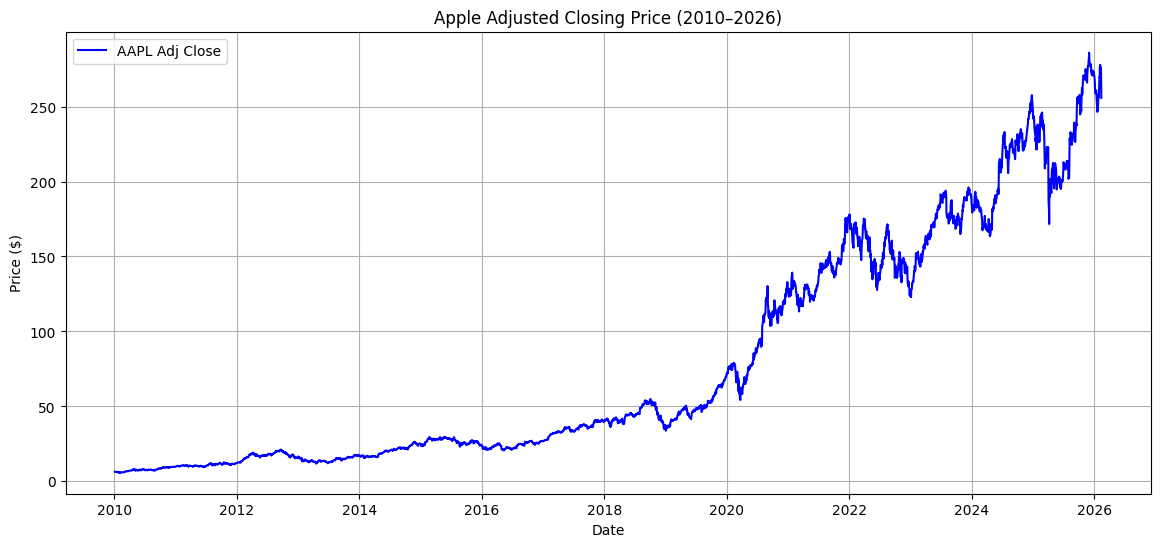

In [4]:

# %%
# Filter for AAPL
aapl = df[df['Ticker'] == 'AAPL'].copy().sort_values('Date')
print(f"AAPL data points: {len(aapl)}")
aapl.head()

# %%
# Plot Adjusted Close price over time
plt.figure(figsize=(14,6))
plt.plot(aapl['Date'], aapl['Adj_Close'], label='AAPL Adj Close', color='blue')
plt.title('Apple Adjusted Closing Price (2010–2026)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

# Feature Engineering

In [5]:

# %%
# Ensure data is sorted by date
aapl = aapl.sort_values('Date').reset_index(drop=True)

# --- Date features ---
aapl['DayOfWeek'] = aapl['Date'].dt.dayofweek
aapl['Month'] = aapl['Date'].dt.month
aapl['Year'] = aapl['Date'].dt.year
aapl['Quarter'] = aapl['Date'].dt.quarter

# --- Lag features (returns and volume) ---
# Daily return (percentage)
aapl['Return'] = aapl['Adj_Close'].pct_change()

# Lagged returns
for lag in [1,2,3,5]:
    aapl[f'Return_lag{lag}'] = aapl['Return'].shift(lag)

# Lagged volume (normalised by its own rolling mean to capture relative changes)
volume_ma = aapl['Volume'].rolling(20).mean()
aapl['Volume_norm'] = aapl['Volume'] / volume_ma
for lag in [1,2,3]:
    aapl[f'Volume_norm_lag{lag}'] = aapl['Volume_norm'].shift(lag)

# --- Rolling statistics ---
# Moving averages of adjusted close
for window in [5, 20, 50]:
    aapl[f'MA_{window}'] = aapl['Adj_Close'].rolling(window).mean()
    aapl[f'Volatility_{window}'] = aapl['Return'].rolling(window).std()

# --- Technical Indicators ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

aapl['RSI_14'] = compute_rsi(aapl['Adj_Close'], 14)


def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

aapl['MACD_line'], aapl['MACD_signal'], aapl['MACD_hist'] = compute_macd(aapl['Adj_Close'])

# Drop rows with NaN created by feature engineering
aapl.dropna(inplace=True)
aapl.reset_index(drop=True, inplace=True)
print(f"Data shape after feature engineering: {aapl.shape}")





Data shape after feature engineering: (4004, 31)


# Define Target and Feature Set

In [6]:
# %%
# Shift target: tomorrow's price
aapl['Target'] = aapl['Adj_Close'].shift(-1)

# Drop the last row (no target)
aapl = aapl.iloc[:-1].copy()

# Features: all columns except identifiers, original OHLCV, and target
exclude_cols = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Target']
feature_cols = [col for col in aapl.columns if col not in exclude_cols]
print("Features used:", feature_cols)

X = aapl[feature_cols]
y = aapl['Target']


Features used: ['DayOfWeek', 'Month', 'Year', 'Quarter', 'Return', 'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Volume_norm', 'Volume_norm_lag1', 'Volume_norm_lag2', 'Volume_norm_lag3', 'MA_5', 'Volatility_5', 'MA_20', 'Volatility_20', 'MA_50', 'Volatility_50', 'RSI_14', 'MACD_line', 'MACD_signal', 'MACD_hist']


# Train/Test Split (Chronological)

In [7]:
# %%
train_size = int(0.8 * len(aapl))
val_size = int(0.1 * len(aapl))
test_size = len(aapl) - train_size - val_size

train_end = train_size
val_end = train_size + val_size

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (3202, 23), Val: (400, 23), Test: (401, 23)


# Scale the Data

In [8]:


# %%
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

# Target scaling (reshape to 2D for scaler)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

# Baseline Model: Random Forest

Random Forest Performance on Test Set:
MAE: $64.79
RMSE: $68.68
R²: -7.5655


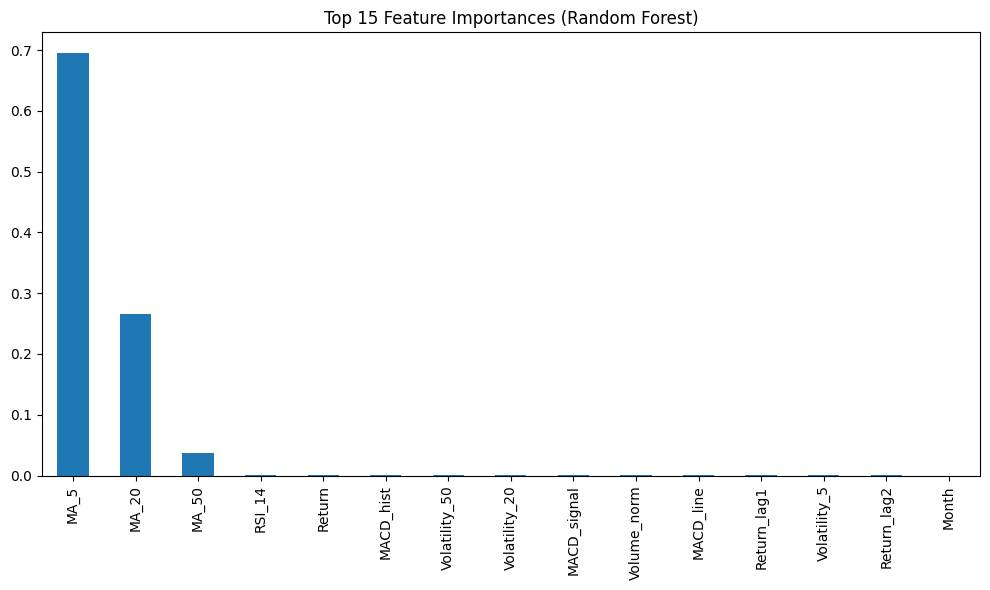

In [9]:

# %%
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_scaled)

# Predictions (scaled)
y_pred_rf_scaled = rf.predict(X_test_scaled)

# Inverse transform to original prices
y_pred_rf = target_scaler.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).flatten()
y_test_orig = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Evaluate
mae_rf = mean_absolute_error(y_test_orig, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf))
r2_rf = r2_score(y_test_orig, y_pred_rf)

print("Random Forest Performance on Test Set:")
print(f"MAE: ${mae_rf:.2f}")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

# Feature importance
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importance.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


#  LSTM Model

LSTM train: (3142, 60, 23), val: (400, 60, 23), test: (401, 60, 23)


I0000 00:00:1771692645.956390      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771692645.962346      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,489 (138.63 KB)

 Trainable params: 35,489 (138.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1771692649.959532      91 cuda_dnn.cc:529] Loaded cuDNN version 91002


99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0232 - mae: 0.0955 - val_loss: 0.0027 - val_mae: 0.0404
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - mae: 0.0358 - val_loss: 0.0023 - val_mae: 0.0372
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - mae: 0.0337 - val_loss: 0.0042 - val_mae: 0.0520
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - mae: 0.0308 - val_loss: 0.0024 - val_mae: 0.0374
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024 - mae: 0.0335 - val_loss: 0.0044 - val_mae: 0.0515
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - mae: 0.0248 - val_loss: 0.0026 - val_mae: 0.0373
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016 - mae: 0.0265 - val_loss: 0.0025 - val_mae: 0.0369
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017 - mae: 0.0270 - val_loss: 0.0028 - val_mae: 0.0427
Epoch 9/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0023 - mae: 0

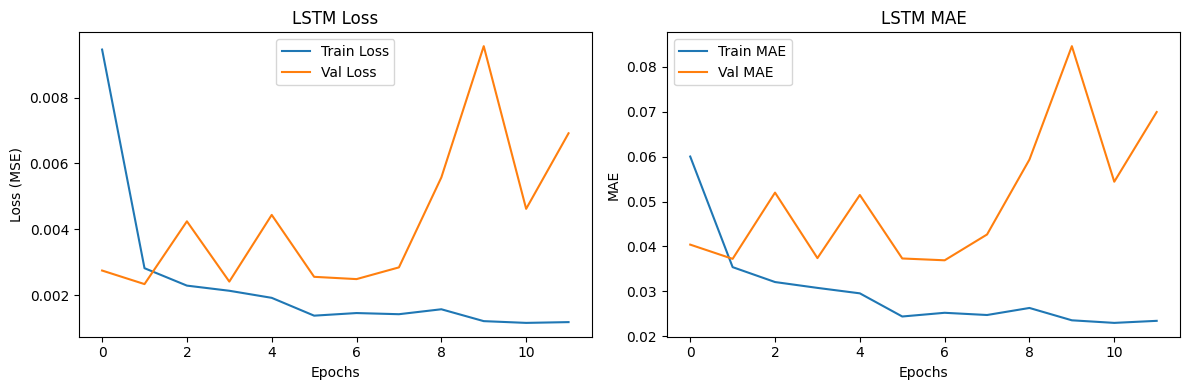

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
LSTM Performance on Test Set:
MAE: $25.70
RMSE: $29.37
R²: -0.5658


In [10]:

# %%
# Function to create sequences
def create_sequences(data, target, lookback=60):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i-lookback:i])
        y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

lookback = 60  # use past 60 days to predict next

# Create sequences from scaled data
# We use the entire dataset (already scaled) and then split, to avoid data leakage.
# Better: create sequences only on training portion and then transform val/test with the training scaler.
# Here we do it properly:

# First, concatenate train+val+test scaled features (already scaled with training scaler)
all_features_scaled = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
all_targets_scaled = np.concatenate([y_train_scaled, y_val_scaled, y_test_scaled])

# Create sequences for the whole set
X_all_seq, y_all_seq = create_sequences(all_features_scaled, all_targets_scaled, lookback)

# Now split back into train/val/test based on indices
# The first `lookback` samples are lost, so adjust index mapping
train_seq_len = len(X_train_scaled) - lookback
val_seq_len = len(X_val_scaled)
test_seq_len = len(X_test_scaled)

X_train_seq = X_all_seq[:train_seq_len]
y_train_seq = y_all_seq[:train_seq_len]

X_val_seq = X_all_seq[train_seq_len:train_seq_len+val_seq_len]
y_val_seq = y_all_seq[train_seq_len:train_seq_len+val_seq_len]

X_test_seq = X_all_seq[train_seq_len+val_seq_len:]
y_test_seq = y_all_seq[train_seq_len+val_seq_len:]

print(f"LSTM train: {X_train_seq.shape}, val: {X_val_seq.shape}, test: {X_test_seq.shape}")


# %%
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# %%
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# %%
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('LSTM Loss')

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('LSTM MAE')
plt.tight_layout()
plt.show()

# %%
# LSTM predictions (scaled)
y_pred_lstm_scaled = model.predict(X_test_seq).flatten()

# Inverse transform
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_test_seq_orig = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Evaluate
mae_lstm = mean_absolute_error(y_test_seq_orig, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq_orig, y_pred_lstm))
r2_lstm = r2_score(y_test_seq_orig, y_pred_lstm)

print("LSTM Performance on Test Set:")
print(f"MAE: ${mae_lstm:.2f}")
print(f"RMSE: ${rmse_lstm:.2f}")
print(f"R²: {r2_lstm:.4f}")

# Compare Predictions

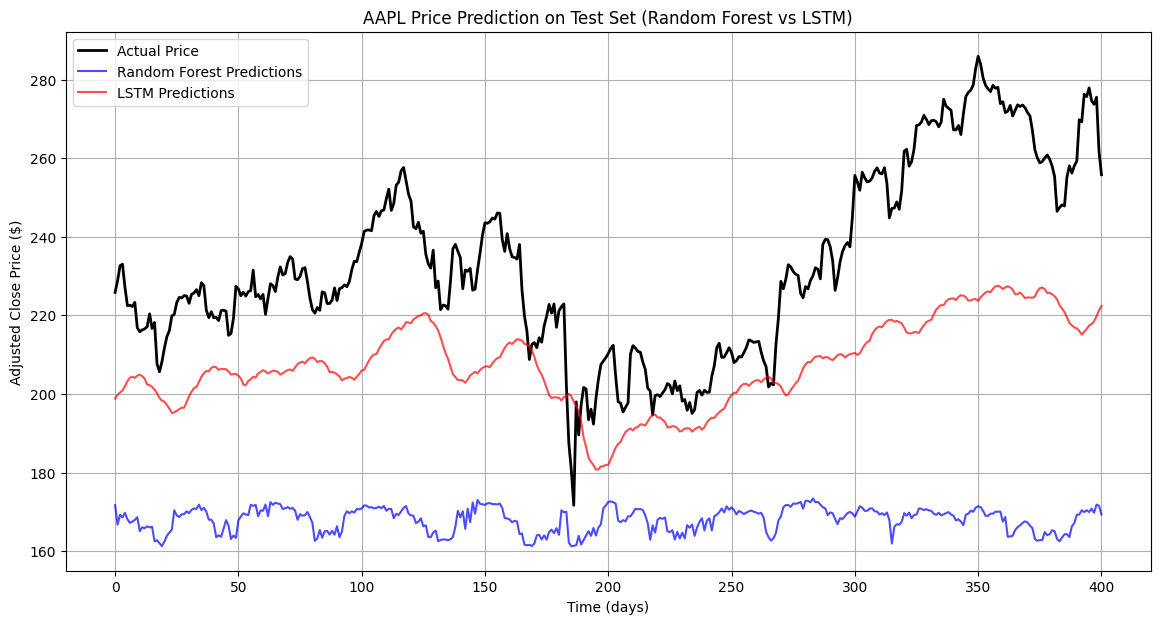

Model Comparison (Test Set):
Model                MAE ($)    RMSE ($)   R²    
--------------------------------------------------
Random Forest        64.79      68.68      -7.5655
LSTM                 25.70      29.37      -0.5658


In [11]:
# %%
# For Random Forest we need to align indices (RF predictions are for all test samples, LSTM has lookback fewer)
# The test set for RF corresponds to indices after the lookback period. We'll take the last len(y_pred_lstm) from RF.
rf_pred_aligned = y_pred_rf[-len(y_pred_lstm):]
rf_actual_aligned = y_test_orig[-len(y_pred_lstm):]

# Plot
plt.figure(figsize=(14,7))
plt.plot(rf_actual_aligned, label='Actual Price', color='black', linewidth=2)
plt.plot(rf_pred_aligned, label='Random Forest Predictions', color='blue', alpha=0.7)
plt.plot(y_pred_lstm, label='LSTM Predictions', color='red', alpha=0.7)
plt.title('AAPL Price Prediction on Test Set (Random Forest vs LSTM)')
plt.xlabel('Time (days)')
plt.ylabel('Adjusted Close Price ($)')
plt.legend()
plt.grid(True)
plt.show()

# %%
# Print comparison
print("Model Comparison (Test Set):")
print(f"{'Model':<20} {'MAE ($)':<10} {'RMSE ($)':<10} {'R²':<6}")
print("-" * 50)
print(f"{'Random Forest':<20} {mae_rf:<10.2f} {rmse_rf:<10.2f} {r2_rf:<6.4f}")
print(f"{'LSTM':<20} {mae_lstm:<10.2f} {rmse_lstm:<10.2f} {r2_lstm:<6.4f}")

#  Quick Multi‑Stock Correlation Analysis

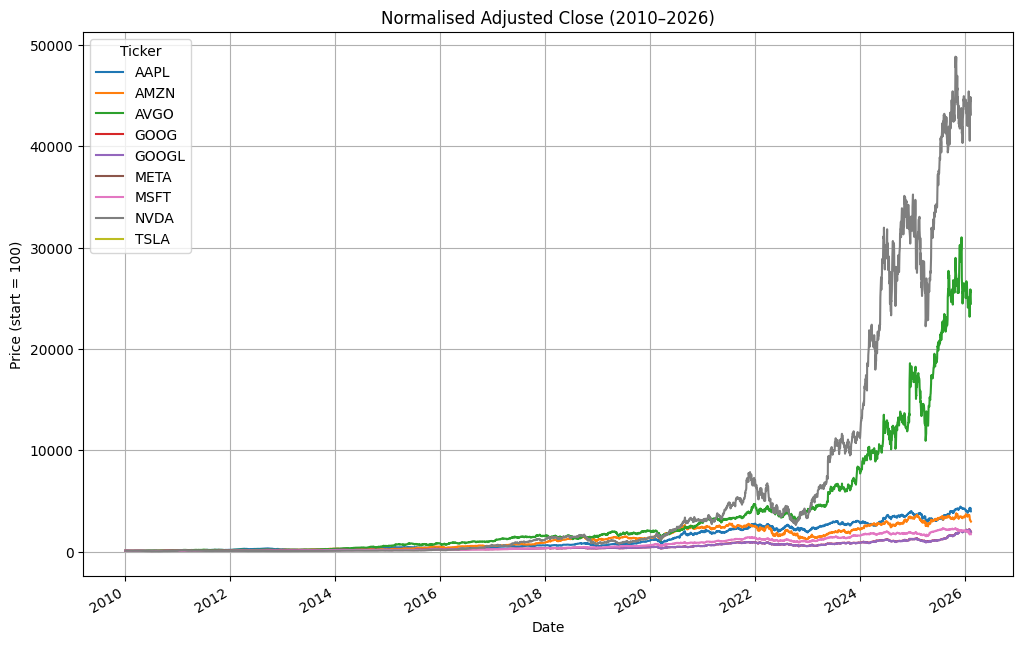

In [12]:
# %%
# Pivot table of adjusted close for all tickers
close_pivot = df.pivot(index='Date', columns='Ticker', values='Adj_Close')
close_pivot.pct_change().corr().style.background_gradient(cmap='coolwarm')

# %%
# Plot closing prices normalised to 100 at start
norm_close = close_pivot.div(close_pivot.iloc[0]).mul(100)
norm_close.plot(figsize=(12,8), title='Normalised Adjusted Close (2010–2026)')
plt.ylabel('Price (start = 100)')
plt.grid(True)
plt.show()